# TASK 1: Credit Scoring Model
**Objective:** Predict an individual's creditworthiness using past financial data.
**Approach:** Logistic Regression, Decision Tree, Random Forest
**Features:** Feature engineering, performance metrics (Precision, Recall, F1-Score, ROC-AUC)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import warnings
warnings.filterwarnings('ignore')

## 1. Dataset Generation
Since we don't have an external dataset provided, we will generate a synthetic dataset containing features such as income, debt, payment history, and credit utilization.

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

n_samples = 1000

# Generating features
income = np.random.normal(60000, 20000, n_samples)
debt = np.random.normal(25000, 12000, n_samples)
years_employed = np.random.poisson(5, n_samples)
late_payments = np.random.poisson(2, n_samples)
credit_history_length = np.random.poisson(8, n_samples)

# Creating the target variable 'creditworthiness' based on a linear combination of features + noise
# 1 = Good Credit, 0 = Bad Credit
score = (income / 10000) * 0.4 - (debt / 10000) * 1.2 + years_employed * 0.3 - late_payments * 1.5 + credit_history_length * 0.2
prob = 1 / (1 + np.exp(-score)) # Sigmoid to get probability
creditworthy = np.where(prob > 0.5, 1, 0)

# Create DataFrame
df = pd.DataFrame({
    'Income': income,
    'Debt': debt,
    'Years_Employed': years_employed,
    'Late_Payments': late_payments,
    'Credit_History_Length': credit_history_length,
    'Creditworthy': creditworthy
})

df.head()

,Income,Debt,Years_Employed,Late_Payments,Credit_History_Length,Creditworthy
0,69934.283060,41792.265239,3,2,10,0
1,57234.713977,36095.604195,6,0,9,1
2,72953.770762,25715.564439,4,1,11,1
3,90460.597128,17236.758668,4,1,8,1
4,55316.932506,33378.679763,8,2,5,0


## 2. Feature Engineering
We will create new features such as `Debt_to_Income_Ratio` which is a crucial indicator of financial health.

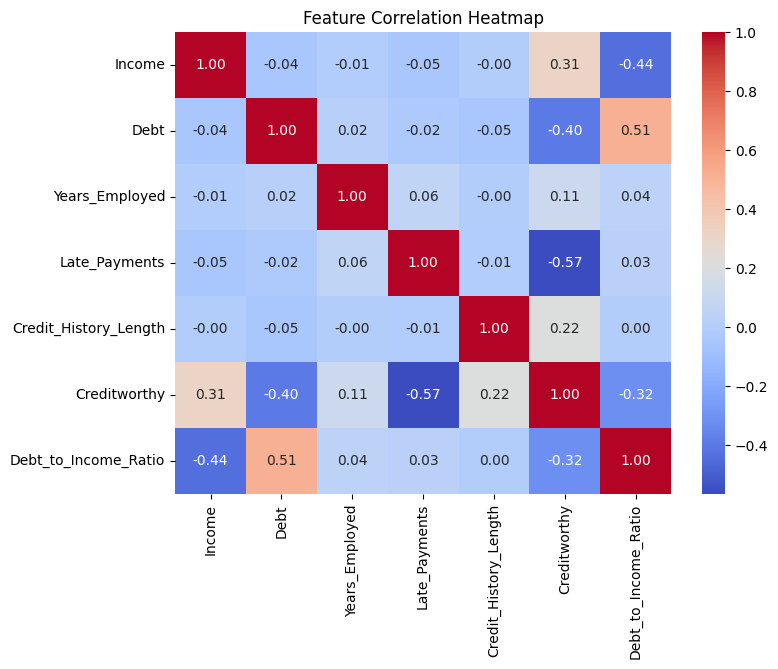

In [3]:
# Feature Engineering: Debt to Income Ratio
df['Debt_to_Income_Ratio'] = df['Debt'] / df['Income']

# Let's check the correlation with the target
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

## 3. Data Preprocessing
Splitting the dataset into train and test sets, and scaling the numerical features.

In [4]:
X = df.drop('Creditworthy', axis=1)
y = df['Creditworthy']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling the numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Model Training and Assessment
We will train three models: Logistic Regression, Decision Tree, and Random Forest. Then we will evaluate them using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

In [5]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    results[name] = {'y_prob': y_prob}

--- Logistic Regression ---
Accuracy: 0.9950
ROC-AUC: 0.9993
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       105
           1       1.00      0.99      0.99        95

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200

--- Decision Tree ---
Accuracy: 0.9250
ROC-AUC: 0.9725
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       105
           1       0.92      0.93      0.92        95

    accuracy                           0.93       200
   macro avg       0.92      0.93      0.92       200
weighted avg       0.93      0.93      0.93       200

--- Random Forest ---
Accuracy: 0.9550
ROC-AUC: 0.9899
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       1

## 5. ROC-AUC Curve Comparison
Visualizing the performance of the models using the ROC curve.

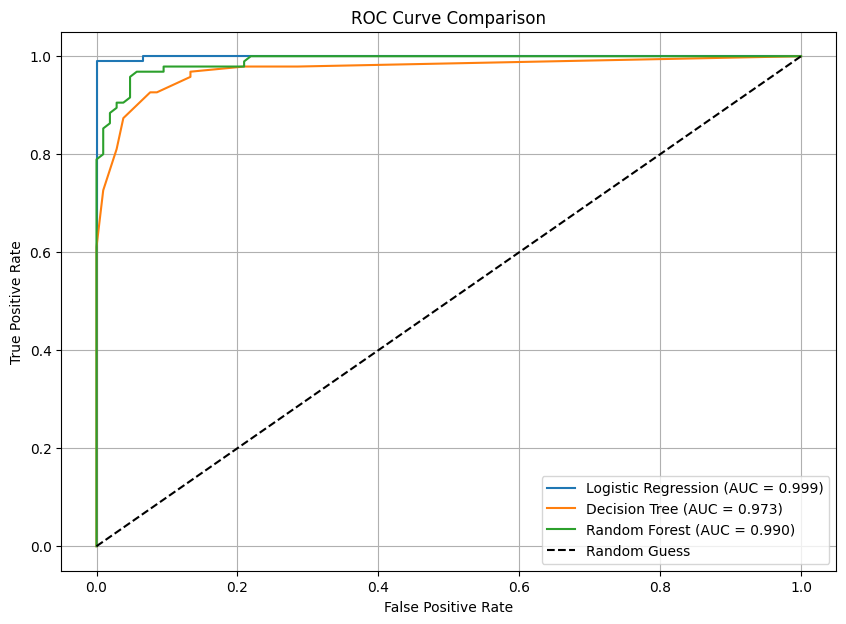

In [6]:
plt.figure(figsize=(10, 7))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    auc = roc_auc_score(y_test, results[name]['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid()
plt.show()

## Conclusion
By engineering relevant financial metrics and applying classification algorithms, we can effectively predict creditworthiness. Based on the metrics above, we can determine the optimal model for our scoring system.